# Exploracion exhaustiva de `sentencias.csv`

Este notebook esta pensado para familiarizarte a fondo con el dataset de sentencias.

Cubre:
- panorama general del archivo y sus columnas
- diagnostico de calidad, placeholders y limpieza
- patrones temporales y distribuciones por tipo de providencia/proceso
- exploracion de magistrados, demandantes, demandados y citaciones
- analisis textual de temas, resumenes, normas y decisiones
- helpers para busqueda, lectura guiada y sentencias parecidas

Recomendacion:
1. Ejecutalo de arriba abajo una primera vez.
2. Luego usa las funciones del final para explorar palabras, temas y sentencias concretas.

In [1]:
from pathlib import Path
import html
import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 160)

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
    SKLEARN_AVAILABLE = True
except Exception as exc:
    SKLEARN_AVAILABLE = False
    print(f"scikit-learn no disponible: {exc}")

DATA_PATH = Path("sentencias.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No encontre {DATA_PATH.resolve()}")

print("Archivo detectado en:", DATA_PATH.resolve())

Archivo detectado en: C:\Users\Sofia\OneDrive - Universidad Nacional de Colombia\Documentos\Maestría Matemática Aplicada\2026-1\Redes Neuronales\Proyecto\Extraccion de articulos\sentencias.csv


## Carga y preparacion

En esta seccion:
- normalizamos nombres de columnas para trabajar mas comodo en Python
- limpiamos HTML, placeholders y caracteres raros
- derivamos variables utiles: prefijo, anos, citaciones numericas y longitudes de texto

In [2]:
def strip_accents(text):
    text = "" if pd.isna(text) else str(text)
    return "".join(
        ch for ch in unicodedata.normalize("NFKD", text)
        if not unicodedata.combining(ch)
    )


def slugify(text):
    text = strip_accents(text).lower()
    text = re.sub(r"[^a-z0-9]+", "_", text).strip("_")
    return text


PLACEHOLDERS = {
    "",
    "-",
    "--",
    "na",
    "n_a",
    "n/d",
    "n.d",
    "nan",
    "none",
    "null",
    "sin informacion",
    "sin dato",
    "sin datos",
    "no aplica",
    "no disponible",
}


def normalize_for_missing(text):
    text = strip_accents(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


def is_missing_like(value):
    return normalize_for_missing(value) in PLACEHOLDERS


def clean_html_text(text):
    text = "" if pd.isna(text) else str(text)
    text = html.unescape(text)
    text = re.sub(r"(?i)<br\s*/?>", "\n", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.replace("¦", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def extract_prefix(text):
    match = re.match(r"^([A-Z]+)", str(text))
    return match.group(1) if match else None


def extract_year_from_id(text):
    match = re.search(r"(\d{2,4})$", str(text))
    if not match:
        return np.nan
    value = int(match.group(1))
    if value >= 100:
        return value
    return 1900 + value if value >= 90 else 2000 + value


def tokenize(text, min_len=4):
    normalized = strip_accents(clean_html_text(text)).lower()
    return re.findall(rf"[a-z]{{{min_len},}}", normalized)


STOPWORDS = {
    "ante", "bajo", "cada", "como", "cual", "cuales", "cuando", "contra",
    "desde", "donde", "entre", "esta", "estas", "este", "estos", "haber",
    "hacia", "hasta", "incluso", "mismo", "mismos", "misma", "mismas",
    "para", "pero", "porque", "segun", "sobre", "tambien", "tras", "tiene",
    "tener", "todos", "todas", "todo", "toda", "solo", "sino", "ser",
    "esta", "estan", "estar", "fue", "fueron", "son", "sea", "han", "hay",
    "del", "las", "los", "que", "por", "con", "una", "uno", "unos", "unas",
    "sin", "sus", "ese", "esa", "eso", "esa", "esas", "esos", "muy", "mas",
    "asi", "aqui", "alli", "corte", "sentencia", "articulo", "articulos",
    "ley", "leyes", "norma", "normas"
}


def top_ngrams(series, ngram=1, top=20, min_len=4):
    counter = Counter()
    for text in series.fillna("").astype(str):
        tokens = [tok for tok in tokenize(text, min_len=min_len) if tok not in STOPWORDS]
        if len(tokens) < ngram:
            continue
        grams = zip(*[tokens[i:] for i in range(ngram)])
        counter.update(" ".join(gram) for gram in grams)
    return pd.DataFrame(counter.most_common(top), columns=["termino", "frecuencia"])


def split_people(text):
    text = clean_html_text(text)
    if is_missing_like(text):
        return []
    parts = re.split(r"\s*(?:;|,|\||/)\s*|\s+y\s+", text)
    return [part.strip() for part in parts if len(part.strip()) >= 4]


raw = pd.read_csv(DATA_PATH)
rename_map = {col: slugify(col) for col in raw.columns}
df = raw.rename(columns=rename_map).copy()

for col in df.columns:
    df[col] = df[col].astype(str)

df["providencia_prefijo"] = df["numero_de_la_providencia"].map(extract_prefix)
df["ano_id"] = df["numero_de_la_providencia"].map(extract_year_from_id)
df["fecha_de_la_providencia_dt"] = pd.to_datetime(df["fecha_de_la_providencia"], errors="coerce")
df["fecha_de_publicacion_dt"] = pd.to_datetime(df["fecha_de_publicacion"], errors="coerce")
df["ano_providencia"] = df["fecha_de_la_providencia_dt"].dt.year
df["ano_publicacion"] = df["fecha_de_publicacion_dt"].dt.year
df["dias_hasta_publicacion"] = (
    df["fecha_de_publicacion_dt"] - df["fecha_de_la_providencia_dt"]
).dt.days

df["citas_num"] = pd.to_numeric(
    df["no_citaciones"].str.replace(r"[^0-9.-]", "", regex=True),
    errors="coerce",
)

text_cols = [
    "temas_y_subtemas",
    "resumen",
    "tema",
    "normas",
    "resuelve_decision",
]

for col in text_cols:
    df[f"{col}_clean"] = df[col].map(clean_html_text)
    df[f"{col}_chars"] = df[f"{col}_clean"].str.len()
    df[f"{col}_words"] = df[f"{col}_clean"].str.split().str.len()

df["texto_total_clean"] = (
    df["temas_y_subtemas_clean"] + " "
    + df["resumen_clean"] + " "
    + df["normas_clean"] + " "
    + df["resuelve_decision_clean"]
).str.strip()
df["texto_total_chars"] = df["texto_total_clean"].str.len()
df["texto_total_words"] = df["texto_total_clean"].str.split().str.len()

original_text_cols = [col for col in raw.columns if rename_map[col] in text_cols]
df["placeholders_por_fila"] = raw.apply(
    lambda row: sum(is_missing_like(value) for value in row.astype(str)),
    axis=1,
)
df["saltos_en_temas"] = raw["Temas y subtemas"].astype(str).str.contains(r"\n")
df["html_en_resumen"] = raw["Resumen"].astype(str).str.contains(r"<br", case=False, regex=True)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas originales: {raw.shape[1]}")
display(pd.DataFrame({
    "columna_original": raw.columns,
    "columna_normalizada": [rename_map[col] for col in raw.columns],
}))

Filas: 922
Columnas originales: 19


,columna_original,columna_normalizada
0,Número de la providencia,numero_de_la_providencia
1,Fecha de la providencia,fecha_de_la_providencia
2,Magistrado(s) Ponentes,magistrado_s_ponentes
3,Magistrado(s) Salvamento/Aclaración,magistrado_s_salvamento_aclaracion
4,Temas y subtemas,temas_y_subtemas
5,Resumen,resumen
6,Tema,tema
7,Tipo de providencia,tipo_de_providencia
8,Tipo de proceso,tipo_de_proceso
9,Sala de seguimiento,sala_de_seguimiento


## 1. Panorama general

Primero miramos tamano, tipos y una vista sintetica por columna.

In [3]:
memory_mb = raw.memory_usage(deep=True).sum() / 1024**2

overview = []
for original_col in raw.columns:
    norm_col = rename_map[original_col]
    series_raw = raw[original_col].astype(str)
    series_clean = df[norm_col].astype(str)
    overview.append({
        "columna_original": original_col,
        "columna_normalizada": norm_col,
        "dtype_raw": str(raw[original_col].dtype),
        "n_unicos": series_raw.nunique(dropna=False),
        "vacios_strict": int(series_raw.str.strip().eq("").sum()),
        "placeholder_like": int(series_raw.map(is_missing_like).sum()),
        "chars_promedio": round(series_clean.map(len).mean(), 1),
        "chars_max": int(series_clean.map(len).max()),
    })

overview_df = pd.DataFrame(overview).sort_values(
    ["placeholder_like", "chars_promedio"], ascending=[False, False]
)

resumen_general = pd.Series({
    "filas": df.shape[0],
    "columnas": df.shape[1],
    "memoria_mb_aprox": round(memory_mb, 2),
    "providencias_unicas": df["numero_de_la_providencia"].nunique(),
    "fechas_providencia_validas": int(df["fecha_de_la_providencia_dt"].notna().sum()),
    "fechas_publicacion_validas": int(df["fecha_de_publicacion_dt"].notna().sum()),
    "citas_numericas_validas": int(df["citas_num"].notna().sum()),
})

display(resumen_general.to_frame("valor"))
display(overview_df)
display(raw.head(3))

,valor
filas,922.00
columnas,48.00
memoria_mb_aprox,6.76
providencias_unicas,922.00
fechas_providencia_validas,922.00
fechas_publicacion_validas,253.00
citas_numericas_validas,866.00


,columna_original,columna_normalizada,dtype_raw,n_unicos,vacios_strict,placeholder_like,chars_promedio,chars_max
13,Autoridades (CJU/ICC),autoridades_cju_icc,str,1,0,922,15.0,15
17,Providencias de seguimiento,providencias_de_seguimiento,str,18,0,905,15.0,31
12,Fecha de publicación,fecha_de_publicacion,str,227,0,669,13.6,15
3,Magistrado(s) Salvamento/Aclaración,magistrado_s_salvamento_aclaracion,str,194,0,662,30.8,323
14,Demandado,demandado,str,213,2,587,19.2,117
5,Resumen,resumen,str,722,0,201,806.8,3698
11,No. Citaciones,no_citaciones,str,113,0,56,2.5,15
16,Normas,normas,str,871,0,52,1250.5,37040
15,Demandante,demandante,str,749,11,42,31.6,250
6,Tema,tema,str,880,0,28,135.2,421


,Número de la providencia,Fecha de la providencia,Magistrado(s) Ponentes,Magistrado(s) Salvamento/Aclaración,Temas y subtemas,Resumen,Tema,Tipo de providencia,Tipo de proceso,Sala de seguimiento,Expediente,No. Citaciones,Fecha de publicación,Autoridades (CJU/ICC),Demandado,Demandante,Normas,Providencias de seguimiento,Resuelve/Decisión
0,C-465/25,2025-11-13,Miguel Efrain Polo Rosero,Natalia Ángel Cabo(AV),"INHIBICION DE LA CORTE CONSTITUCIONAL POR INEPTITUD SUSTANTIVA DE LA DEMANDA-Incumplimiento de requisitos de claridad, certeza, especificidad, pertinencia y suficiencia en los cargos\nINHIBICION D...","Demanda de inconstitucionalidad contra el artículo 7 (parcial) de la Ley 2277 de 2022, por medio de la cual se adopta una reforma tributaria para la igualdad y la justicia social y se dictan otras...",Fallo inhibitorio por ineptitud sustantiva de demanda formulada en contra de norma del Estatuto Tributario que establece regla para deducir renta líquida gravable de la cédula general.,Constitucionalidad,Demandas Ordinarias,Sala plena/Revisión,D-16426,1,2026-01-13,Sin Información,LEY 22 77 DE 2022,CHICA RAMÍREZ JUAN GUILLERMO Y OTROS,"Ley 22 77 de 2022 (por medio de la cual se adopta una reforma tributaria para la igualdad y la justicia social y se dictan otras disposiciones), Artículo 7 parcial¦",Sin Información,"RESUELVE\nÚNICO: Declararse INHIBIDA para adoptar un pronunciamiento de fondo sobre la demanda de inconstitucionalidad presentada por los ciudadanos Juan Guillermo Chica Ramírez, Juan Felipe Díez ..."
1,C-464/25,2025-11-13,Juan Carlos Cortés González,Sin Información,INHIBICION DE LA CORTE CONSTITUCIONAL-Incumplimiento de requisitos exigidos en cargo por violación del principio de equidad tributaria\nCONCEPTO DE VIOLACION EN DEMANDA DE INCONSTITUCIONALIDAD-Raz...,"Demanda de inconstitucionalidad en contra del artículo 25 (parcial) del Decreto 624 de 1989 (Estatuto Tributario), modificado por el artículo 84 de la Ley 2010 de 2019. La norma acusada establece ...","Fallo inhibitorio por ineptitud sustantiva de la demanda formulada en contra de norma que establece tratamiento para los Centros de Distribución de Logística Internacional, ubicados únicamente en ...",Constitucionalidad,Demandas Ordinarias,Sala plena/Revisión,D-16206,1,2026-03-10,Sin Información,DECRETO 624 DE 1989,FORERO JIMÉNEZ CARLOS Y OTRO,"Decreto 624 de 1989 (Por el cual se expide el Estatuto Tributario de los Impuestos Administrados por la Dirección General de Impuestos Nacionales), Artículo 25, literal C) modificado por el artícu...",Sin Información,"RESUELVE\nÚNICO. Declararse INHIBIDA para emitir un pronunciamiento de fondo sobre la demanda de inconstitucionalidad contra la expresión ""ubicados en aeropuertos internacionales, puertos marítimo..."
2,C-431/25,2025-10-16,Paola Andrea Meneses Mosquera,Carlos Camargo Assis(SV)\nJorge Enrique Ibáñez Najar(AV)\nMiguel Efrain Polo Rosero(AV)\nPaola Andrea Meneses Mosquera(AV)\nVladimir Fernández Andrade(AV),ESTADO DE CONMOCIÓN INTERIOR-Requisito de la firma del Presidente y de todos los ministros\nDECRETO LEGISLATIVO EXPEDIDO EN DESARROLLO DEL ESTADO DE CONMOCIÓN INTERIOR EN LA REGIÓN DEL CATATUMBO-E...,"Control de constitucionalidad del Decreto Legislativo 175 de 14 de febrero de 2025, por el cual se adoptan medidas tributarias destinadas a atender los gastos del Presupuesto General de la Nación ...","Revisión de constitucionalidad de decreto legislativo que adopta medidas tributarias para atender gastos del Presupuesto General de la Nación, expedido en el marco del estado de conmoción interior...",Constitucionalidad,Decretos Legislativos,Sala plena/Revisión,RE-380,6,2025-12-19,Sin Información,--,DECRETO LEGISLATIVO 175 DE 2025,Decreto Legislativo 175 de 2025 (Por el cual se adoptan medidas tributarias destinadas a atender los gastos del Presupuesto General de la Nación necesarios para hacer frente al estado de conmoción...,Sin Información,"RESUELVE\nPRIMERO. Declarar EXEQUIBLES los artículos 1 (parágrafos 1, 

## 2. Calidad de datos

Aqui buscamos:
- duplicados
- placeholders y blancos
- consistencia entre el ano del identificador y la fecha
- HTML / caracteres raros incrustados

In [4]:
quality_summary = pd.Series({
    "duplicados_fila_completa": int(raw.duplicated().sum()),
    "duplicados_numero_providencia": int(df["numero_de_la_providencia"].duplicated().sum()),
    "blancos_en_demandante": int(df["demandante"].str.strip().eq("").sum()),
    "resumen_con_html_br": int(df["html_en_resumen"].sum()),
    "temas_con_saltos_de_linea": int(df["saltos_en_temas"].sum()),
    "normas_con_char_raro": int(df["normas"].str.contains("¦", regex=False).sum()),
    "filas_con_placeholders": int((df["placeholders_por_fila"] > 0).sum()),
    "max_placeholders_en_una_fila": int(df["placeholders_por_fila"].max()),
    "mismatch_ano_id_vs_fecha": int((df["ano_id"] != df["ano_providencia"]).fillna(False).sum()),
})

placeholder_top = []
for original_col in raw.columns:
    counts = (
        raw[original_col]
        .astype(str)
        .map(normalize_for_missing)
        .value_counts()
    )
    for token in ["sin informacion", "", "--"]:
        if token in counts:
            placeholder_top.append({
                "columna": original_col,
                "token": token if token else "<blanco>",
                "frecuencia": int(counts[token]),
            })

placeholder_top = pd.DataFrame(placeholder_top).sort_values(
    ["frecuencia", "columna"], ascending=[False, True]
)

display(quality_summary.to_frame("valor"))
display(placeholder_top.head(20))

quality_view = raw.loc[
    df["placeholders_por_fila"].sort_values(ascending=False).index[:10],
    ["Número de la providencia", "Tema", "Demandado", "Demandante", "Sala de seguimiento", "Autoridades (CJU/ICC)"],
].copy()
quality_view.insert(1, "placeholders_por_fila", df["placeholders_por_fila"].sort_values(ascending=False).head(10).to_list())
display(quality_view)

,valor
duplicados_fila_completa,0
duplicados_numero_providencia,0
blancos_en_demandante,11
resumen_con_html_br,47
temas_con_saltos_de_linea,921
normas_con_char_raro,870
filas_con_placeholders,922
max_placeholders_en_una_fila,8
mismatch_ano_id_vs_fecha,0


,columna,token,frecuencia
6,Autoridades (CJU/ICC),sin informacion,922
14,Providencias de seguimiento,sin informacion,905
5,Fecha de publicación,sin informacion,669
0,Magistrado(s) Salvamento/Aclaración,sin informacion,662
7,Demandado,sin informacion,576
2,Resumen,sin informacion,201
4,No. Citaciones,sin informacion,56
13,Normas,sin informacion,52
10,Demandante,sin informacion,28
3,Tema,sin informacion,28


,Número de la providencia,placeholders_por_fila,Tema,Demandado,Demandante,Sala de seguimiento,Autoridades (CJU/ICC)
904,T-458/05,8,Sin Información,Sin Información,OMAR ANDRES VITERI DUARTE VS. IDU,Sala plena/Revisión,Sin Información
916,T-754/03,8,DERECHOS A LA SALUD TRABAJO FAMILIA RELIGION CULTURA Y DIGNIDAD DE MENORES DE EDAD. SOLICITUD RECUPERACION BIENES QUE INGRESARON DE ISRAEL A COLOMBIA. TRAMITE DE IMPORTACION DE MENAJE. DECLARACION...,Sin Información,SAMUEL SASSON BELTRAN Y OTRA VS. DIAN Y OTRO,Sala plena/Revisión,Sin Información
908,T-775/04,8,DERECHO A ACCEDER A LA JUSTICIA Y A OBTENER UNA TUTELA JUDICIAL EFECTIVA DENTRO DE UN PROCESO DE COBRO ADELANTADO POR LA DIAN EN EL QUE SE EMBARGO Y SECUESTRO UN BIEN INMUEBLE DE PROPIEDAD DE LA S...,Sin Información,EUFREDO ENRIQUE CHARRIS SANJUANELO VS. DIAN,Sala plena/Revisión,Sin Información
853,C-466/93,7,LEY 6/92. ARTS 24 Y 25. NORMAS EN MATERIA TRIBUTARIA. IVA. COSA JUZGADA. REMITE A C-094. EXEQUIBLES.,Sin Información,ALEXANDRE VERNOT,Sala plena/Revisión,Sin Información
915,T-863/03,7,DERECHO AL DEBIDO PROCESO. VIA DE HECHO. ADMINISTRACION DE JUSTICIA. SOLICITUD NULIDAD DE TODO LO ACTUADO EN PROCESO EJECUTIVO. FALTA PAGO IMPUESTO DE TIMBRE DE TITULO VALOR PAGARE. OPERACION DE C...,Sin Información,BANCOLOMBIA PANAMA S.A. VS. TRIBUNAL SUPERIOR DE SANTA MARTA,Sala plena/Revisión,Sin Información
884,T-716/12,7,Sin Información,SECCION CUARTA DEL CONSEJO DE ESTADO,MARVAL S.A.,Sala plena/Revisión,Sin Información
840,C-373/94,7,DEC. 1264/94. EXENCIONES TRIBUTARIAS PARA LAS ZONAS DE CALAMIDAD PUBLICA DEL HUILA Y CAUCA. EXEQUIBLE.,Sin Información,,Sala plena/Revisión,Sin Información
827,C-117/96,7,DEC. 624/89. ART. 16 PARCIAL. ESTATUTO TRIBUTARIO. IMPUESTO SOBRE LA RENTA. EXEQUIBLE. VER <A HREF=../1995/C-587-95.rtf> C-587/95</A>.,Sin Información,JOSE EDUARDO VALDIVIA LARA,Sala plena/Revisión,Sin Información
846,C-062/94,7,LEY 6/92. ART. 107 PARCIAL. ELIMINACION DEL FONDO ROTATORIO DE ADUANAS. COSA JUZGADA. ESTARSE A LO RESUELTO EN LA <A HREF=../1993/C-544-93.rtf> C-544/93</A>.,Sin Información,LUIS MARIO COBOS,Sala plena/Revisión,Sin Información
842,C-200/94,7,LEY 6/92. ART. 107 PARCIAL. FONDO ROTATORIO DE ADUANAS. ESTARSE A LO RESUELTO EN LA <A HREF=../1993/C-544-93.rtf> C-544/93</A>.,Sin Información,PAULINA RICO,Sala plena/Revisión,Sin Información


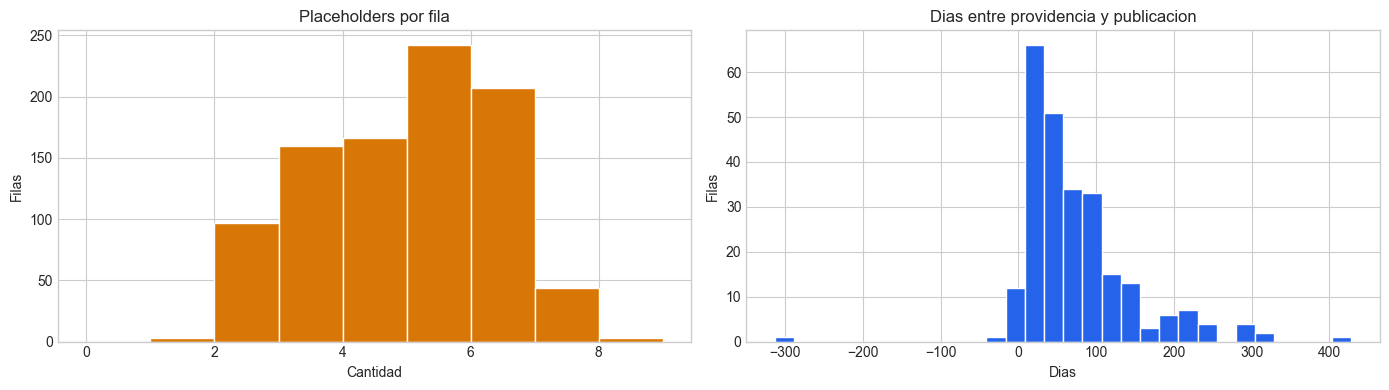

,numero_de_la_providencia,fecha_de_la_providencia,fecha_de_publicacion,dias_hasta_publicacion,tipo_de_providencia,tipo_de_proceso
13,C-031/25,2025-02-04,2026-04-08,428.0,Constitucionalidad,Demandas Ordinarias
341,C-843/10,2010-10-28,2011-09-05,312.0,Constitucionalidad,Decretos Legislativos
68,C-208/22,2022-06-09,2023-04-11,306.0,Constitucionalidad,Demandas Ordinarias
8,C-180/25,2025-05-14,2026-03-12,302.0,Constitucionalidad,Demandas Ordinarias
203,C-308/17,2017-05-10,2018-02-26,292.0,Constitucionalidad,Demandas Ordinarias
7,C-182/25,2025-05-14,2026-02-27,289.0,Constitucionalidad,Demandas Ordinarias
133,C-097/20,2020-03-03,2020-12-16,288.0,Constitucionalidad,Demandas Ordinarias
52,C-384/23,2023-10-02,2024-06-06,248.0,Constitucionalidad,Demandas Ordinarias
178,C-232/19,2019-05-29,2020-01-30,246.0,Constitucionalidad,Demandas Ordinarias
51,C-389/23,2023-10-04,2024-05-29,238.0,Constitucionalidad,Demandas Ordinarias


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["placeholders_por_fila"], bins=range(int(df["placeholders_por_fila"].max()) + 2), color="#d97706", edgecolor="white")
axes[0].set_title("Placeholders por fila")
axes[0].set_xlabel("Cantidad")
axes[0].set_ylabel("Filas")

lag = df["dias_hasta_publicacion"].dropna()
axes[1].hist(lag, bins=30, color="#2563eb", edgecolor="white")
axes[1].set_title("Dias entre providencia y publicacion")
axes[1].set_xlabel("Dias")
axes[1].set_ylabel("Filas")

plt.tight_layout()
plt.show()

display(
    df.loc[
        df["dias_hasta_publicacion"].sort_values(ascending=False).index[:10],
        [
            "numero_de_la_providencia",
            "fecha_de_la_providencia",
            "fecha_de_publicacion",
            "dias_hasta_publicacion",
            "tipo_de_providencia",
            "tipo_de_proceso",
        ],
    ]
)

## 3. Estructura del universo de sentencias

Revisamos el dataset por tiempo y por categorias clave.

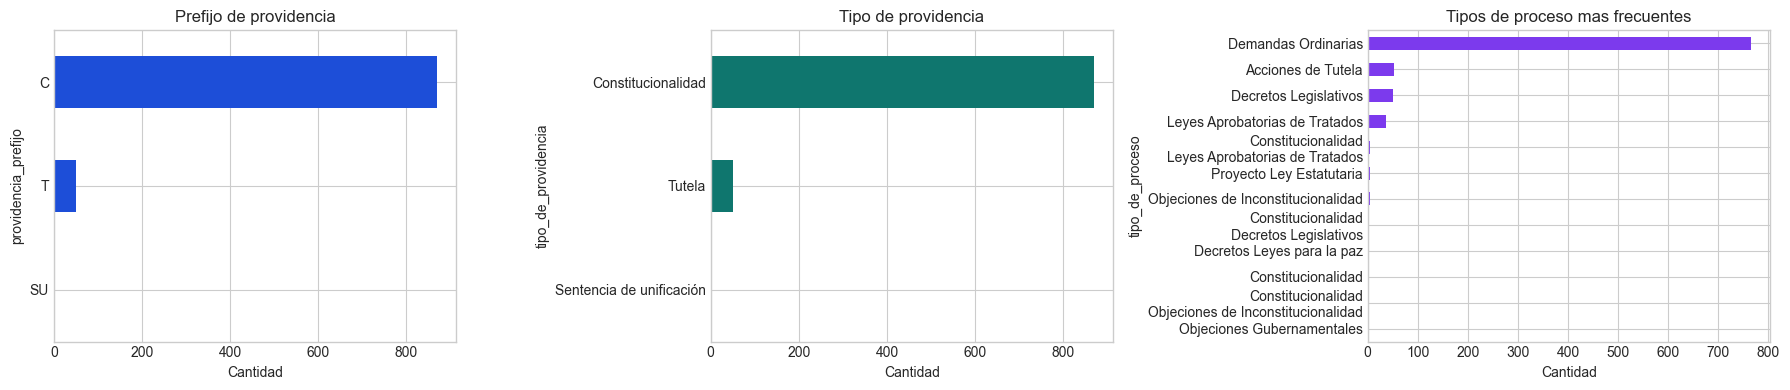

providencia_prefijo,C,SU,T
ano_providencia,,,
2006,30,0,2
2007,27,0,2
2008,22,0,1
2009,24,0,5
2010,23,0,4
2011,22,0,1
2012,27,0,2
2013,21,0,0
2014,19,0,3


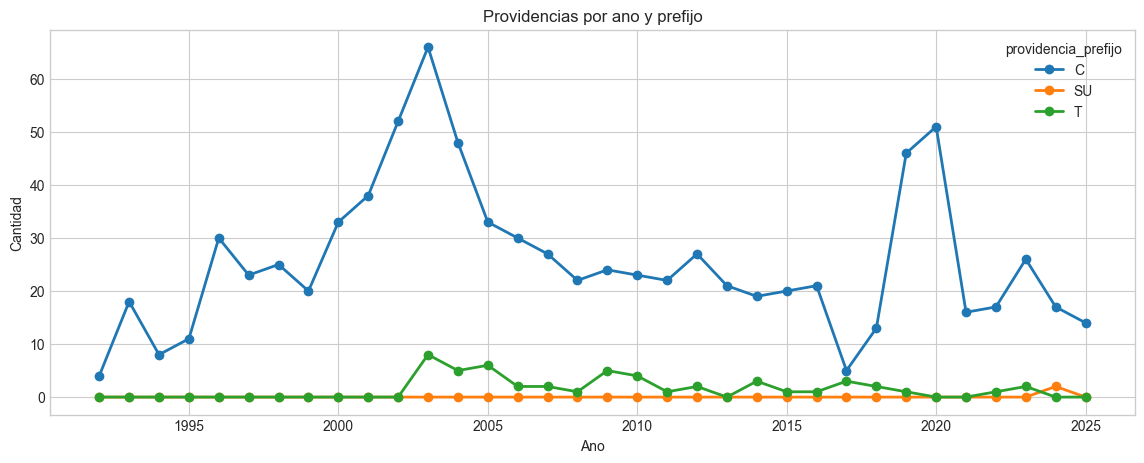

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

(
    df["providencia_prefijo"]
    .value_counts()
    .sort_values()
    .plot(kind="barh", ax=axes[0], color="#1d4ed8")
)
axes[0].set_title("Prefijo de providencia")
axes[0].set_xlabel("Cantidad")

(
    df["tipo_de_providencia"]
    .value_counts()
    .sort_values()
    .plot(kind="barh", ax=axes[1], color="#0f766e")
)
axes[1].set_title("Tipo de providencia")
axes[1].set_xlabel("Cantidad")

(
    df["tipo_de_proceso"]
    .value_counts()
    .head(12)
    .sort_values()
    .plot(kind="barh", ax=axes[2], color="#7c3aed")
)
axes[2].set_title("Tipos de proceso mas frecuentes")
axes[2].set_xlabel("Cantidad")

plt.tight_layout()
plt.show()

yearly = (
    df.groupby(["ano_providencia", "providencia_prefijo"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
display(yearly.tail(20))
yearly.plot(figsize=(14, 5), marker="o", linewidth=2)
plt.title("Providencias por ano y prefijo")
plt.xlabel("Ano")
plt.ylabel("Cantidad")
plt.show()

tipo_de_providencia,Constitucionalidad,Sentencia de unificación,Tutela
providencia_prefijo,,,
C,870,0,0
SU,0,2,0
T,0,0,50


tipo_de_proceso,Acciones de Tutela,Constitucionalidad,Constitucionalidad\nDecretos Legislativos,Constitucionalidad\nLeyes Aprobatorias de Tratados,Constitucionalidad\nObjeciones de Inconstitucionalidad,Decretos Legislativos,Decretos Leyes para la paz,Demandas Ordinarias,Leyes Aprobatorias de Tratados,Objeciones Gubernamentales,Objeciones de Inconstitucionalidad,Proyecto Ley Estatutaria
tipo_de_providencia,,,,,,,,,,,,
Constitucionalidad,0,1,1,5,1,50,1,765,36,1,4,5
Sentencia de unificación,2,0,0,0,0,0,0,0,0,0,0,0
Tutela,50,0,0,0,0,0,0,0,0,0,0,0


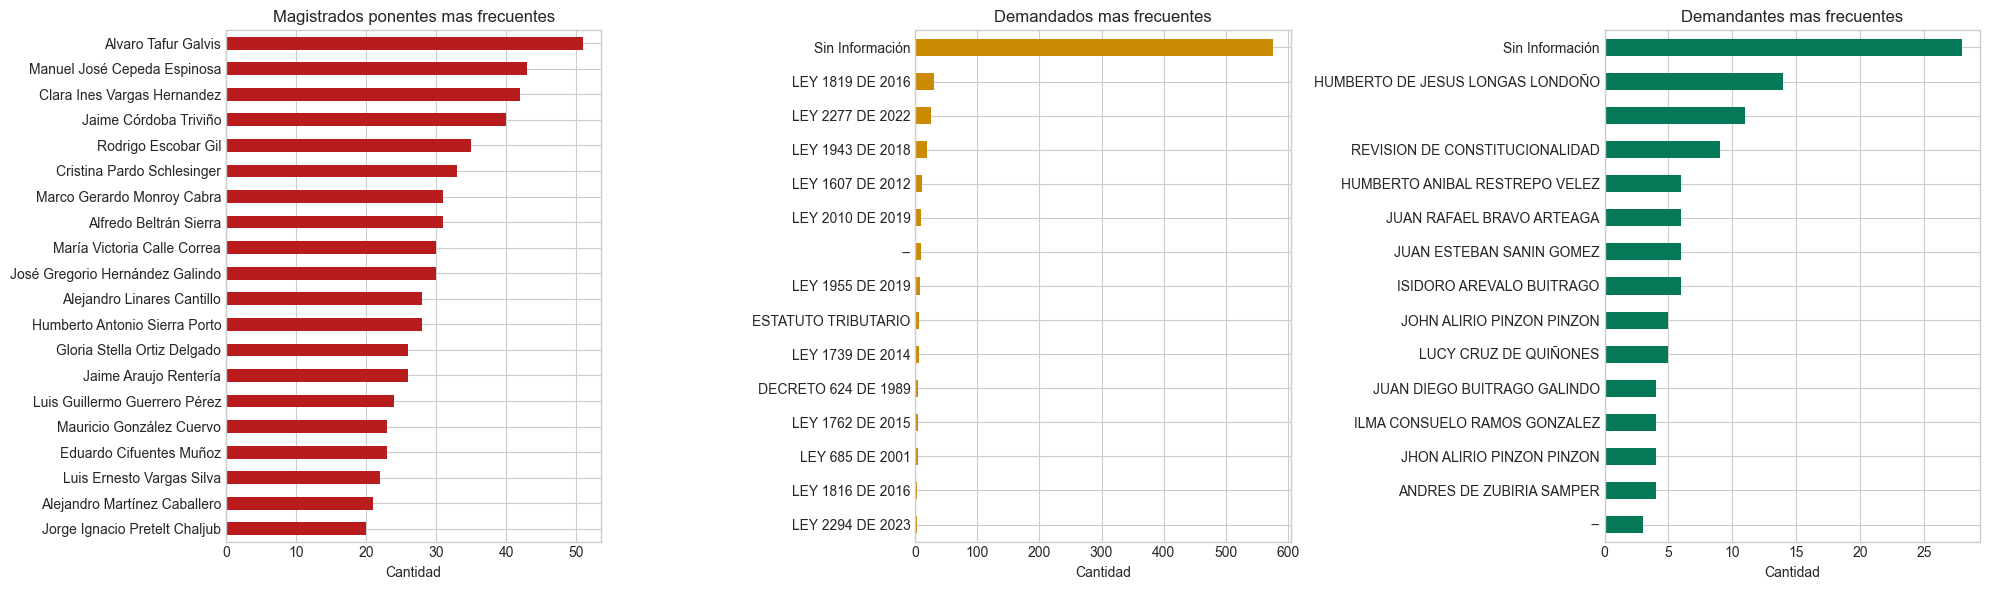

,ponente,frecuencia
0,Alvaro Tafur Galvis,51
1,Manuel José Cepeda Espinosa,43
2,Clara Ines Vargas Hernandez,42
3,Jaime Córdoba Triviño,40
4,Rodrigo Escobar Gil,35
5,Cristina Pardo Schlesinger,33
6,Marco Gerardo Monroy Cabra,31
7,Alfredo Beltrán Sierra,31
8,María Victoria Calle Correa,30
9,José Gregorio Hernández Galindo,30


In [7]:
tipo_vs_proceso = pd.crosstab(df["tipo_de_providencia"], df["tipo_de_proceso"])
tipo_vs_prefijo = pd.crosstab(df["providencia_prefijo"], df["tipo_de_providencia"])

display(tipo_vs_prefijo)
display(tipo_vs_proceso)

magistrados_raw = Counter()
for text in df["magistrado_s_ponentes"]:
    magistrados_raw.update(split_people(text))

ponentes_df = pd.DataFrame(
    magistrados_raw.most_common(20),
    columns=["ponente", "frecuencia"]
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ponentes_df.iloc[::-1].plot(
    kind="barh",
    x="ponente",
    y="frecuencia",
    ax=axes[0],
    color="#b91c1c",
    legend=False,
)
axes[0].set_title("Magistrados ponentes mas frecuentes")
axes[0].set_xlabel("Cantidad")
axes[0].set_ylabel("")

(
    df["demandado"]
    .value_counts()
    .head(15)
    .sort_values()
    .plot(kind="barh", ax=axes[1], color="#ca8a04")
)
axes[1].set_title("Demandados mas frecuentes")
axes[1].set_xlabel("Cantidad")
axes[1].set_ylabel("")

(
    df["demandante"]
    .replace("", "<blanco>")
    .value_counts()
    .head(15)
    .sort_values()
    .plot(kind="barh", ax=axes[2], color="#047857")
)
axes[2].set_title("Demandantes mas frecuentes")
axes[2].set_xlabel("Cantidad")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

display(ponentes_df.head(20))

## 4. Citaciones, fechas y casos extremos

Esta parte sirve para identificar sentencias especialmente visibles, antiguas, recientes o densas.

,citas_num
count,866.000000
mean,25.948037
std,31.481175
min,1.000000
25%,6.000000
50%,14.500000
75%,33.000000
90%,61.000000
95%,88.000000
max,241.000000


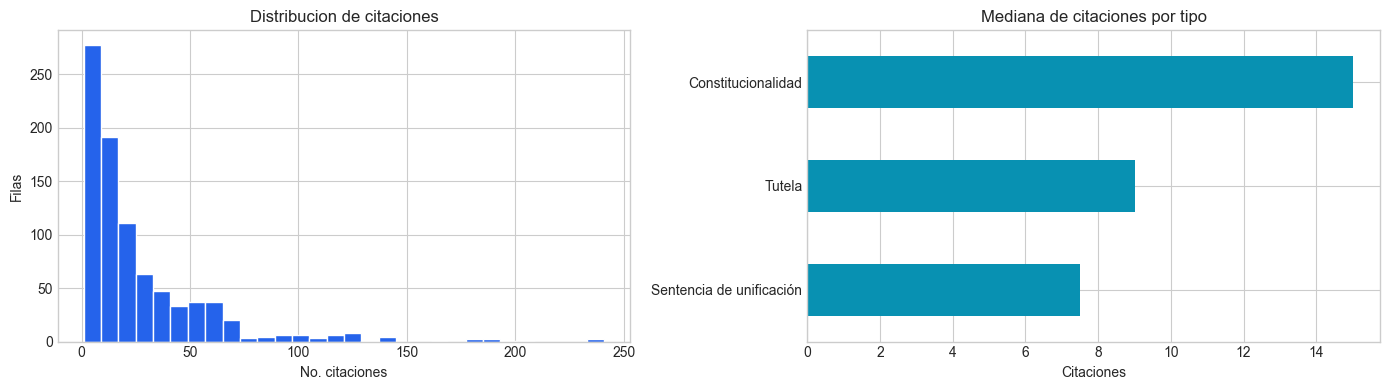

,numero_de_la_providencia,fecha_de_la_providencia,tipo_de_providencia,tipo_de_proceso,citas_num,tema
756,C-478/98,1998-09-09,Constitucionalidad,Demandas Ordinarias,241.0,LEY 223/95. ART. 285 PARCIAL. RACIONALIZACION TRIBUTARIA. DEROGATORIAS Y VIGENCIAS. EXEQUIBLE.
246,C-951/14,2014-12-04,Constitucionalidad,Proyecto Ley Estatutaria,238.0,PROYECTO DE LEY ESTATUTARIA SOBRE DERECHO FUNDAMENTAL DE PETICION
869,C-479/92,1992-08-13,Constitucionalidad,Demandas Ordinarias,208.0,LEY 60/92 ART. 2. . RETIRO DEL SERVICIO DE FUNCIONARIOS PUBLICOS. PREAMBULO DE LA C.N. CARRERA ADMIN. EXEQUIBLE . DEC. 1660/91. INEXEQUIBLE.
680,C-992/01,2001-09-19,Constitucionalidad,Demandas Ordinarias,197.0,DECLARACION DE IMPUESTO SOBRE LA RENTA Y COMPLEMENTARIOS. TÉRMINOS PERENTORIOS PARA REVISIÓN Y CORRECCIÓN POR ADMINISTRACIÓN
391,C-1011/08,2008-10-16,Constitucionalidad,Proyecto Ley Estatutaria,185.0,PROYECTO DE LEY ESTATUTARIA DE HABEAS DATA Y MANEJO DE INFORMACION CONTENIDA EN BASES DE DATOS PERSONALES
566,C-776/03,2003-09-09,Constitucionalidad,Demandas Ordinarias,185.0,LEY 788 DE 2002. ARTS. 8 29 (P.) 34 57 69 70 71 72 73 74 114 Y 116. EXPEDICION NORMAS TRIBUTARIAS Y PENALES DEL ORDEN NACIONAL Y TERRITORIAL. REMATE DE BIENES. SOBRETASA A CARGO DEL CONTRIBUYENTE ...
360,C-894/09,2009-12-02,Constitucionalidad,Demandas Ordinarias,182.0,FALLO INHIBITORIO POR INEPTITUD DE DEMANDA DE INCONSTITUCIONALIDAD CONTRA NORMA DE LA LEY 1289 DE 2009
320,C-748/11,2011-10-06,Constitucionalidad,Proyecto Ley Estatutaria,178.0,PROYECTO DE LEY ESTATUTARIA DE HABEAS DATA Y PROTECCION DE DATOS PERSONALES
396,C-750/08,2008-07-24,Constitucionalidad,Leyes Aprobatorias de Tratados,161.0,CONTROL DE CONSTITUCIONALIDAD DEL ACUERDO DE PROMOCION COMERCIAL ENTRE LA REPUBLICA DE COLOMBIA Y LOS ESTADOS UNIDOS DE AMERICA
337,C-978/10,2010-12-01,Constitucionalidad,Demandas Ordinarias,143.0,"ASIGNACION DE LA FUNCION DE DESARROLLAR, ORGANIZAR Y PONER EN FUNCIONAMIENTO EL SERVICIO AEREO MEDICALIZADO A LA ENTIDAD QUE AGREMIA NACIONALMENTE A LOS MUNICIPIOS COLOMBIANOS. VULNERA PRINCIPIO D..."


,numero_de_la_providencia,fecha_de_la_providencia,tipo_de_providencia,tipo_de_proceso,tema
869,C-479/92,1992-08-13,Constitucionalidad,Demandas Ordinarias,LEY 60/92 ART. 2. . RETIRO DEL SERVICIO DE FUNCIONARIOS PUBLICOS. PREAMBULO DE LA C.N. CARRERA ADMIN. EXEQUIBLE . DEC. 1660/91. INEXEQUIBLE.
868,C-575/92,1992-10-29,Constitucionalidad,Demandas Ordinarias,LEY 49/90. ART 68 NUM 2 y 3. CAJAS DE COMPENSACION FAMILIAR. SUBSIDIO DE VIVIENDA. EXEQUIBLES.
867,C-599/92,1992-12-10,Constitucionalidad,Demandas Ordinarias,DEC. 1746/91. ARTS 7 PARCIAL 19 PARCIAL 21 PARCIAL 26 Y 27 PARCIAL. INFRACCIONES CAMBIARIAS. DEBIDO PROCESO. EXEQUIBLES SALVO ART 27.
866,C-608/92,1992-12-14,Constitucionalidad,Demandas Ordinarias,DEC. 2911/91. LEY 49/90. ART 25. AJUSTES INTEGRALES POR INFLACION. FACULTADES EXTRAORDINARIAS. INEXEQUIBLE DEC 2911/91. EXEQUIBLE ART 25 LEY 49/90.
865,C-015/93,1993-01-21,Constitucionalidad,Demandas Ordinarias,DEC 624/89. ART 278. ESTATUTO TRIBUTARIO. CONSTITUCIONAL
864,C-094/93,1993-02-27,Constitucionalidad,Demandas Ordinarias,LEY 6/92. ART. 24 y 25. NORMAS EN MATERIA TRIBUTARIA. IVA. EXEQUIBLE.
863,C-103/93,1993-03-11,Constitucionalidad,Demandas Ordinarias,ESTATUTO TRIBUTARIO. EXEQUIBLE
862,C-115/93,1993-03-25,Constitucionalidad,Demandas Ordinarias,DEC. 0624/89. ART. 124. ESTATUTO TRIBUTARIO. EXEQUIBLES ALGUNAS EXPRESIONES
861,C-144/93,1993-04-20,Constitucionalidad,Demandas Ordinarias,NORMAS EN MATERIA TRIBUTARIA. TARIFAS. PROPIEDAD INDUSTRIAL.
860,C-205/93,1993-05-27,Constitucionalidad,Demandas Ordinarias,LEY 6/92. ARTS 16. 17 Y 18. BONOS DE GUERRA. INEXEQUIBLES.


,numero_de_la_providencia,fecha_de_la_providencia,tipo_de_providencia,tipo_de_proceso,tema
0,C-465/25,2025-11-13,Constitucionalidad,Demandas Ordinarias,Fallo inhibitorio por ineptitud sustantiva de demanda formulada en contra de norma del Estatuto Tributario que establece regla para deducir renta líquida gravable de la cédula general.
1,C-464/25,2025-11-13,Constitucionalidad,Demandas Ordinarias,"Fallo inhibitorio por ineptitud sustantiva de la demanda formulada en contra de norma que establece tratamiento para los Centros de Distribución de Logística Internacional, ubicados únicamente en ..."
2,C-431/25,2025-10-16,Constitucionalidad,Decretos Legislativos,"Revisión de constitucionalidad de decreto legislativo que adopta medidas tributarias para atender gastos del Presupuesto General de la Nación, expedido en el marco del estado de conmoción interior..."
3,C-317/25,2025-07-24,Constitucionalidad,Demandas Ordinarias,IMPUESTO COMPLEMENTARIO A LAS GANANCIAS OCASIONALES DE LAS INDEMNIZACIONES POR SEGUROS DE VIDA TIENE EN CUENTA LA CAPACIDAD CONTRIBUTIVA DE LOS SUJETOS OBLIGADOS. NO DESCONOCE EL PRINCIPIO DE EQUI...
4,C-248/25,2025-06-11,Constitucionalidad,Decretos Legislativos,"REVISIÓN DE CONSTITUCIONALIDAD DE DECRETO LEGISLATIVO QUE ESTABLECE MEDIDAS TRANSITORIAS EN MATERIA DE TURISMO, EXPEDIDO EN EL MARCO DEL ESTADO DE CONMOCIÓN INTERIOR DECLARADO EN LA REGIÓN DEL CAT..."
5,C-244/25,2025-06-11,Constitucionalidad,Demandas Ordinarias,"INEXEQUIBLE NORMA DEL PLAN NACIONAL DE DESARROLLO QUE MODIFICA LA TEMPORALIDAD DE LA CONTRIBUCIÓN NACIONAL DE VALORIZACIÓN, POR INCUMPLIR EL PRINCIPIO DE UNIDAD DE MATERIA. APROXIMACIÓN UNIFICADA..."
6,C-197/25,2025-05-22,Constitucionalidad,Demandas Ordinarias,INEXEQUIBLE NORMA QUE RESTRINGE EL USO DE LAS LISTAS DE ELEGIBLES CUANDO EL CARGO DE LA DIAN SE ENCUENTRA PROVISTO EN ENCARGO O PROVISIONALIDAD POR VIOLAR EL PRINCIPIO DEL MÉRITO Y LOS DERECHOS FU...
7,C-182/25,2025-05-14,Constitucionalidad,Demandas Ordinarias,"Exequible norma que faculta a los concejos municipales de las ciudades capitales para adoptar, bajo determinadas condiciones, las normas que rigen para Bogotá en materia de impuestos predial e ICA..."
8,C-180/25,2025-05-14,Constitucionalidad,Demandas Ordinarias,Fallo inhibitorio por ineptitud sustantiva de la demanda formulada en contra de norma que modificó el límite de renta exenta sobre los pagos laborales recibidos por personas naturales que perciben...
9,C-099/25,2025-03-20,Constitucionalidad,Demandas Ordinarias,"\nIMPUESTO NACIONAL SOBRE PRODUCTOS PLÁSTICOS DE UN SOLO USO UTILIZADOS PARA ENVASAR, EMBALAR O EMPACAR BIENES. INEXEQUIBLE EXPRESIÓN “PARA CONSUMO PROPIO”.\n"


In [8]:
citas_stats = df["citas_num"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame("citas_num")
display(citas_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["citas_num"].dropna(), bins=30, color="#2563eb", edgecolor="white")
axes[0].set_title("Distribucion de citaciones")
axes[0].set_xlabel("No. citaciones")
axes[0].set_ylabel("Filas")

grouped = (
    df.groupby("tipo_de_providencia")["citas_num"]
    .median()
    .sort_values()
)
grouped.plot(kind="barh", ax=axes[1], color="#0891b2")
axes[1].set_title("Mediana de citaciones por tipo")
axes[1].set_xlabel("Citaciones")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

columns_view = [
    "numero_de_la_providencia",
    "fecha_de_la_providencia",
    "tipo_de_providencia",
    "tipo_de_proceso",
    "citas_num",
    "tema",
]

display(df.nlargest(15, "citas_num")[columns_view])
display(df.nsmallest(10, "fecha_de_la_providencia_dt")[columns_view[:4] + ["tema"]])
display(df.nlargest(10, "fecha_de_la_providencia_dt")[columns_view[:4] + ["tema"]])

## 5. Exploracion textual

Aqui medimos longitud, vocabulario y expresiones frecuentes.

Ojo:
- el dataset tiene mucho texto juridico y tributario
- varias columnas traen saltos de linea o HTML
- `Tema` parece mas corto y mas resumido; `Temas y subtemas`, `Normas` y `Resuelve/Decision` suelen ser mas ricos

,chars_min,chars_mediana,chars_promedio,chars_max,words_promedio
temas_y_subtemas,15,1117,1756.2,25383,216.9
resumen,15,811,803.6,3652,127.9
tema,15,122,134.1,420,19.5
normas,15,788,1241.4,36265,197.8
resuelve_decision,113,397,627.9,25921,104.4


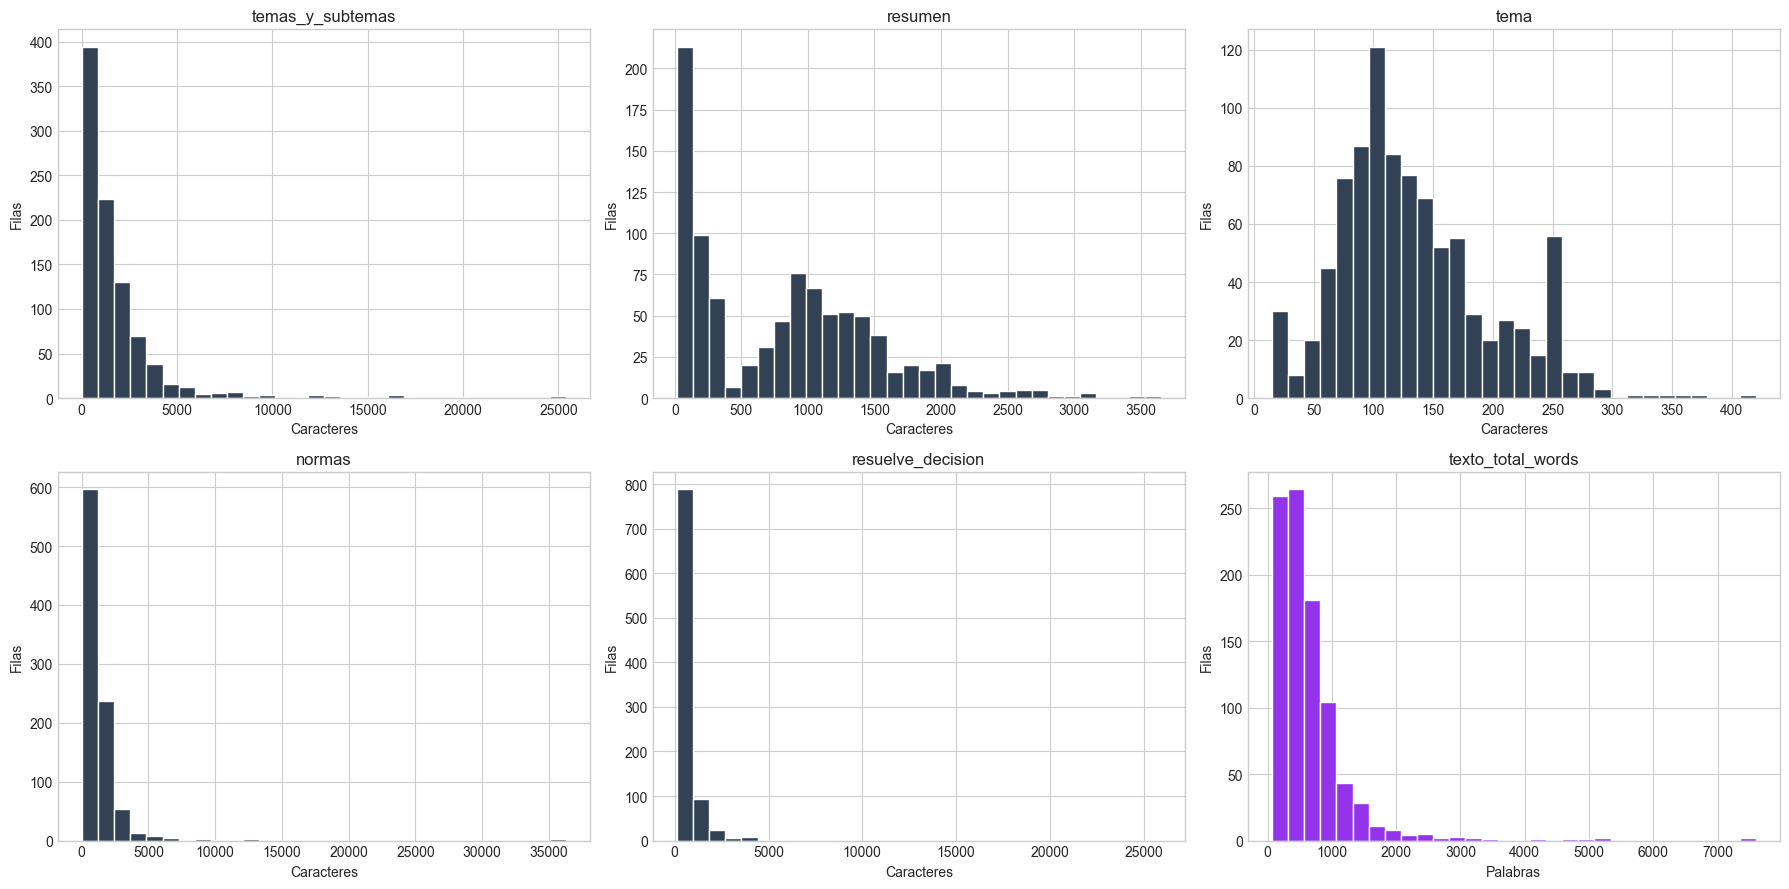

,numero_de_la_providencia,tipo_de_providencia,texto_total_chars,tema,resumen_clean
419,C-517/07,Constitucionalidad,41535,CONCEJO MUNICIPAL EN MATERIA TRIBUTARIA. EJERCICIO DE ATRIBUCIONES DEBE SUJETARSE A LA CONSTITUCIÓN Y LA LEY,LEY 44 DE 1990 ARTICULOS 1 2 4 5 6 8 9 10 12 13 14 15 16 Y 17; LEY 601 DE 2000 ARTICULOS 1 4 5 6 Y 7; LEY 14 DE 1983 ARTICULO 30; DECRETO 1333 DE 1986 ARTICULOS 186 193 194 220 221 222 Y 233 LITER...
298,C-540/12,Constitucionalidad,40652,PROYECTO DE LEY ESTATUTARIA DE FORTALECIMIENTO DEL MARCO JURIDICO PARA EL DESARROLLO DE LAS ACTIVIDADES DE INTELIGENCIA Y CONTRAINTELIGENCIA,"Revisión de constitucionalidad del proyecto de ley estatutaria No. 263/11 Senado y 195/11 Cámara, por medio del cual se expiden normas para fortalecer el marco jurídico que permite a los organismo..."
754,C-495/98,Constitucionalidad,39850,VARIOS ARTICULOS DE LAS SIGUIENTES NORMAS. DEC. 1344/70. LEY 14/83. LEY 23/86. DEC. 1333/86. LEY 9/89 LEY 44/90. LEY 3/91 LEY 6/92 LEY 99/93 LEY 136/94 LEY 181/95 LEY 300/96 LEY 388/97. EXEQ. E IN...,Sin Información
224,C-035/16,Constitucionalidad,35810,RESERVAS MINERAS ESTRATÉGICAS. SISTEMA NACIONAL PINES. CONTRATOS DE CONCESIÓN ESPECIAL PARA EXPLOTACIÓN MINERA. PRÓRROGAS. NO DEVOLUCIÓN DE PREDIOS A VÍCTIMAS EN ESTAS ZONAS E INDEMNIZACIÓN. SERVI...,"Demanda de inconstitucionalidad contra el artículo 108 de la ley 1450 de 2011, por la cual se aprueba el Plan Nacional de Desarrollo 2010-2014 y contra los artículos 20, 49, 59 (parcial), 51, 52 (..."
278,C-274/13,Constitucionalidad,35235,PROYECTO DE LEY ESTATUTARIA QUE CREA LEY DE TRANSPARENCIA Y DERECHO DE ACCESO A LA INFORMACION PUBLICA NACIONAL,"Revisión de constitucionalidad del Proyecto de Ley Estatutaria número 228 de 2012 Cámara, 156 de 2011 Senado, por medio de la cual se crea la ley de transparencia y del derecho de acceso a la info..."
246,C-951/14,Constitucionalidad,34484,PROYECTO DE LEY ESTATUTARIA SOBRE DERECHO FUNDAMENTAL DE PETICION,"Revisión de constitucionalidad del Proyecto de Ley número 65 de 2012 Senado y número 227 de 2013, Cámara, por medio del cual se regula el derecho fundamental de petición y se sustituye un título d..."
871,T-235/23,Tutela,27826,DERECHO A LA IGUALDAD DE CULTOS EN ASUNTO TRIBUTARIO Y PRINCIPIO DE LAICIDAD EN EL ESTADO COLOMBIANO-COMPETENCIA DE LOS ENTES TERRITORIALES EN MATERIA DE SOBRETASA AMBIENTAL.,"El accionante, en nombre y representación de la Iglesia del Dios Vivo, organización de naturaleza religiosa debidamente reconocida por el estado colombiano considera que la Corporación Autónoma de..."
215,C-209/16,Constitucionalidad,26958,IMPUESTO NACIONAL AL CONSUMO. POR EL EXPENDIO DE COMIDAS Y BEBIDAS,"Demanda de inconstitucionalidad contra el numeral 3 (parcial), del artículo 71 de la Ley 1607 de 2012, por la cual se expiden normas en materia tributaria y se dictan otras disposiciones. Se plant..."
210,C-389/16,Constitucionalidad,23050,"CÓDIGO DE MINAS. PROCEDIMIENTO DE PROPUESTAS DE CONCESIÓN MINERA. PRELACIÓN DE GRUPOS INDÍGENAS. ZONAS MINERAS INDÍGENAS. MANEJO AMBIENTAL, OPOSICIONES. CELEBRACIÓN Y REGISTRO DEL CONTRATO DE CONC...","Demanda de inconstitucionalidad contra los artículos 16, 53, 122, 124, 128, 270, 271, 272, 273, 274, 275, 276, 277 y 279 de la Ley 685 de 2001, por la cual se expide el Código de Minas y se dictan..."
639,C-614/02,Constitucionalidad,20824,PROYECTO DE ACTO LEGISLATIVO. MODIFICACIONES QUE NO CONSTITUYEN UNA INICIATIVA NUEVA O UN CAMBIO SUSTANCIAL INADMISIBLE,ACTO LEGISLATIVO 01 DE 2001. ARTS. 1 2 Y 3 (PS.). MODIFICA ARTICULOS DE LA CONSTITUCION. LEY ANUAL DE PRESUPUESTO. APROPIACIONES. SISTEMA GENERAL DE PARTICIPACIONES. TRANSFERENCIA A ENTIDADES TERR...


In [9]:
text_length_summary = pd.DataFrame({
    "chars_min": [int(df[f"{col}_chars"].min()) for col in text_cols],
    "chars_mediana": [int(df[f"{col}_chars"].median()) for col in text_cols],
    "chars_promedio": [round(df[f"{col}_chars"].mean(), 1) for col in text_cols],
    "chars_max": [int(df[f"{col}_chars"].max()) for col in text_cols],
    "words_promedio": [round(df[f"{col}_words"].mean(), 1) for col in text_cols],
}, index=text_cols)

display(text_length_summary)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, text_cols):
    ax.hist(df[f"{col}_chars"], bins=30, color="#334155", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Caracteres")
    ax.set_ylabel("Filas")

axes[-1].hist(df["texto_total_words"], bins=30, color="#9333ea", edgecolor="white")
axes[-1].set_title("texto_total_words")
axes[-1].set_xlabel("Palabras")
axes[-1].set_ylabel("Filas")

plt.tight_layout()
plt.show()

long_view = [
    "numero_de_la_providencia",
    "tipo_de_providencia",
    "texto_total_chars",
    "tema",
    "resumen_clean",
]
display(df.nlargest(10, "texto_total_chars")[long_view])

In [10]:
global_terms = top_ngrams(
    df["temas_y_subtemas_clean"] + " " + df["resumen_clean"] + " " + df["resuelve_decision_clean"],
    ngram=1,
    top=30,
)
global_bigrams = top_ngrams(
    df["temas_y_subtemas_clean"] + " " + df["resumen_clean"] + " " + df["resuelve_decision_clean"],
    ngram=2,
    top=25,
)

display(global_terms)
display(global_bigrams)

for tipo in df["tipo_de_providencia"].value_counts().index:
    print(f"\n=== Top terminos para: {tipo} ===")
    subset = df.loc[df["tipo_de_providencia"] == tipo, "texto_total_clean"]
    display(top_ngrams(subset, ngram=1, top=15))

,termino,frecuencia
0,principio,2924
1,tributaria,2445
2,constitucional,2140
3,materia,2041
4,impuesto,1753
5,constitucion,1636
6,estado,1512
7,legislativo,1378
8,demanda,1361
9,control,1349


,termino,frecuencia
0,demanda inconstitucionalidad,877
1,estado emergencia,825
2,nombre pueblo,815
3,materia tributaria,811
4,mandato constitucion,811
5,pueblo mandato,809
6,decreto legislativo,715
7,economica social,671
8,emergencia economica,669
9,constitucion resuelve,662



=== Top terminos para: Constitucionalidad ===


,termino,frecuencia
0,principio,3371
1,tributaria,3186
2,materia,2650
3,constitucional,2378
4,declarar,2282
5,impuesto,2201
6,decreto,2109
7,constitucion,1896
8,demanda,1738
9,legislativo,1706



=== Top terminos para: Tutela ===


,termino,frecuencia
0,tutela,199
1,accion,168
2,proceso,119
3,secretaria,105
4,derecho,86
5,administrativo,75
6,impuesto,75
7,debido,74
8,informacion,68
9,sala,67



=== Top terminos para: Sentencia de unificación ===


,termino,frecuencia
0,tutela,14
1,judiciales,13
2,proceso,13
3,defecto,11
4,providencias,11
5,nulidad,11
6,accion,11
7,cosa,9
8,juzgada,9
9,restablecimiento,9


,keyword,sentencias,porcentaje
2,iva,729,79.1
15,exequible,711,77.1
0,tribut,669,72.6
1,impuesto,500,54.2
7,igualdad,264,28.6
16,inexequible,246,26.7
13,cosa juzgada,213,23.1
9,libertad,210,22.8
14,inhibicion,199,21.6
5,contribucion,129,14.0


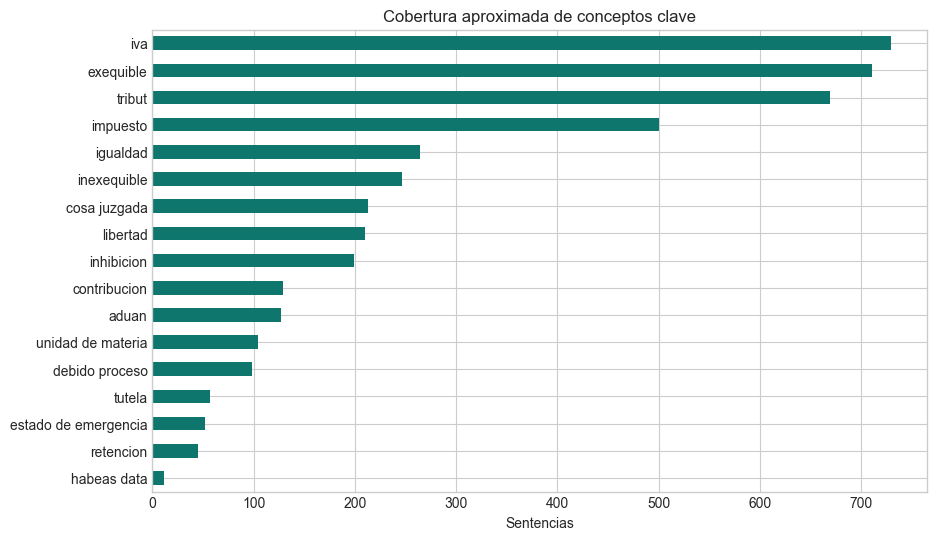

In [11]:
KEYWORDS = [
    "tribut", "impuesto", "iva", "retencion", "aduan", "contribucion",
    "tutela", "igualdad", "debido proceso", "libertad", "habeas data",
    "estado de emergencia", "unidad de materia", "cosa juzgada",
    "inhibicion", "exequible", "inexequible"
]

keyword_rows = []
for keyword in KEYWORDS:
    pattern = strip_accents(keyword).lower()
    mask = (
        df["texto_total_clean"]
        .map(lambda x: strip_accents(x).lower())
        .str.contains(pattern, regex=False)
    )
    keyword_rows.append({
        "keyword": keyword,
        "sentencias": int(mask.sum()),
        "porcentaje": round(mask.mean() * 100, 1),
    })

keyword_df = pd.DataFrame(keyword_rows).sort_values("sentencias", ascending=False)
display(keyword_df)

keyword_df.set_index("keyword")["sentencias"].sort_values().plot(
    kind="barh", figsize=(10, 6), color="#0f766e"
)
plt.title("Cobertura aproximada de conceptos clave")
plt.xlabel("Sentencias")
plt.ylabel("")
plt.show()

## 6. Helpers para explorar mejor

Estas funciones son la parte mas util para seguir familiarizandote con el corpus.

In [12]:
VIEW_COLS = [
    "numero_de_la_providencia",
    "fecha_de_la_providencia",
    "tipo_de_providencia",
    "tipo_de_proceso",
    "magistrado_s_ponentes",
    "demandante",
    "demandado",
    "citas_num",
    "tema",
]


def buscar_sentencias(consulta, campo="texto_total_clean", n=10, case=False):
    if campo not in df.columns:
        raise KeyError(f"Campo no encontrado: {campo}")
    serie = df[campo].fillna("").astype(str)
    mask = serie.str.contains(consulta, case=case, regex=False)
    result = df.loc[mask, VIEW_COLS + [campo]].copy()
    result["match_chars"] = result[campo].str.len()
    return result.sort_values(["citas_num", "match_chars"], ascending=[False, False]).head(n)


def ver_sentencia(identificador, max_chars=2500):
    if isinstance(identificador, str):
        mask = df["numero_de_la_providencia"].str.upper() == identificador.upper()
        if not mask.any():
            raise ValueError(f"No encontre la sentencia {identificador}")
        row = df.loc[mask].iloc[0]
    else:
        row = df.iloc[int(identificador)]

    meta = row[VIEW_COLS]
    display(meta.to_frame("valor"))

    for col in ["temas_y_subtemas_clean", "resumen_clean", "normas_clean", "resuelve_decision_clean"]:
        snippet = row[col][:max_chars]
        display(Markdown(f"### {col}\n\n{snippet}"))


if SKLEARN_AVAILABLE:
    similarity_corpus = df["resumen_clean"].where(
        df["resumen_clean"].str.len() > 40,
        df["tema_clean"]
    ).fillna("")

    vectorizer = TfidfVectorizer(
        strip_accents="unicode",
        lowercase=True,
        min_df=3,
        stop_words=sorted(STOPWORDS),
    )
    X = vectorizer.fit_transform(similarity_corpus)

    def sentencias_parecidas(identificador, n=5):
        mask = df["numero_de_la_providencia"].str.upper() == str(identificador).upper()
        if not mask.any():
            raise ValueError(f"No encontre la sentencia {identificador}")
        idx = int(np.flatnonzero(mask.to_numpy())[0])
        sims = cosine_similarity(X[idx], X).ravel()
        order = np.argsort(sims)[::-1]
        order = [i for i in order if i != idx][:n]
        cols = VIEW_COLS + ["resumen_clean"]
        result = df.iloc[order][cols].copy()
        result.insert(0, "similitud", sims[order])
        return result

    print("Helper de similitud listo: sentencias_parecidas('C-465/25')")
else:
    print("Sin scikit-learn: se omite sentencias_parecidas().")

Helper de similitud listo: sentencias_parecidas('C-465/25')


In [13]:
display(buscar_sentencias("iva", n=8))
display(buscar_sentencias("unidad de materia", n=8))
display(buscar_sentencias("estado de emergencia", n=8))

if SKLEARN_AVAILABLE:
    display(sentencias_parecidas("C-465/25", n=8))

,numero_de_la_providencia,fecha_de_la_providencia,tipo_de_providencia,tipo_de_proceso,magistrado_s_ponentes,demandante,demandado,citas_num,tema,texto_total_clean,match_chars
756,C-478/98,1998-09-09,Constitucionalidad,Demandas Ordinarias,Alejandro Martínez Caballero,MARCO GERARDO MONROY CABRA,Sin Información,241.0,LEY 223/95. ART. 285 PARCIAL. RACIONALIZACION TRIBUTARIA. DEROGATORIAS Y VIGENCIAS. EXEQUIBLE.,CERTIFICADO DE DESARROLLO TURISTICO-Congreso podía derogarlo en ejercicio de su libertad política CERTIFICADO DE DESARROLLO TURISTICO-Derogación no viola derechos adquiridos de inversionistas CONG...,1421
246,C-951/14,2014-12-04,Constitucionalidad,Proyecto Ley Estatutaria,Martha Victoria Sáchica Méndez,REVISION DE CONSTITUCIONALIDAD DEL PROYECTO DE LEY 62/12 SENADO Y 227/13 CAMARA,Sin Información,238.0,PROYECTO DE LEY ESTATUTARIA SOBRE DERECHO FUNDAMENTAL DE PETICION,ACCESO A LA INFORMACION-Principios rectores ACTIVIDAD PERIODISTICA-Garantías ATENCION PRIORITARIA DE PETICIONES-Contenido normativo ATENCION PRIORITARIA DE PETICIONES-Preferencia que se da a las p...,34484
869,C-479/92,1992-08-13,Constitucionalidad,Demandas Ordinarias,José Gregorio Hernández Galindo,PEDRO SUAREZ Y OTROS,Sin Información,208.0,LEY 60/92 ART. 2. . RETIRO DEL SERVICIO DE FUNCIONARIOS PUBLICOS. PREAMBULO DE LA C.N. CARRERA ADMIN. EXEQUIBLE . DEC. 1660/91. INEXEQUIBLE.,CONTROL DE CONSTITUCIONALIDAD- EXCEPCION DE INCONSTITUCIONALIDAD- UNIDAD NORMATIVA- DERECHO AL TRABAJO-Garantía FUNCIÓN PÚBLICA-Eficiencia RETIRO DEL SERVICIO-Compensación PREAMBULO-Vulneración CA...,2264
680,C-992/01,2001-09-19,Constitucionalidad,Demandas Ordinarias,Rodrigo Escobar Gil,HUMBERTO DE JESUS LONGAS LONDOÑO,Sin Información,197.0,DECLARACION DE IMPUESTO SOBRE LA RENTA Y COMPLEMENTARIOS. TÉRMINOS PERENTORIOS PARA REVISIÓN Y CORRECCIÓN POR ADMINISTRACIÓN,PRESUNCION EN IMPUESTO INDIRECTO- AMNISTIA TRIBUTARIA-Inexequibilidad futura por situaciones jurídicas consolidadas BASE GRAVABLE DEL IMPUESTO SOBRE LA RENTA-Determinación legislativa CLAUSULA DE ...,16077
391,C-1011/08,2008-10-16,Constitucionalidad,Proyecto Ley Estatutaria,Jaime Córdoba Triviño,Sin Información,Sin Información,185.0,PROYECTO DE LEY ESTATUTARIA DE HABEAS DATA Y MANEJO DE INFORMACION CONTENIDA EN BASES DE DATOS PERSONALES,PROYECTO DE LEY ESTATUTARIA DE HABEAS DATA Y MANEJO DE INFORMACION CONTENIDA EN BASES DE DATOS PERSONALES- AGENCIAS DE INFORMACION COMERCIAL-Doble carácter de operador y fuente de información AGEN...,20016
566,C-776/03,2003-09-09,Constitucionalidad,Demandas Ordinarias,Manuel José Cepeda Espinosa,ANDRES DE ZUBIRIA SAMPER,Sin Información,185.0,LEY 788 DE 2002. ARTS. 8 29 (P.) 34 57 69 70 71 72 73 74 114 Y 116. EXPEDICION NORMAS TRIBUTARIAS Y PENALES DEL ORDEN NACIONAL Y TERRITORIAL. REMATE DE BIENES. SOBRETASA A CARGO DEL CONTRIBUYENTE ...,ACTIVIDAD SANCIONADORA DE LA ADMINISTRACION EN MATERIA TRIBUTARIA-Persigue lograr fines constitucionales específicos AMNISTIA TRIBUTARIA-Efectos BIEN O SERVICIO GRAVADO-Adquisición constituye un i...,14493
360,C-894/09,2009-12-02,Constitucionalidad,Demandas Ordinarias,Gabriel Eduardo Mendoza Martelo,JUAN CARLOS ARANGO RODRIGUEZ,LEY 1298 DE 2009 ARTÍCULO 1,182.0,FALLO INHIBITORIO POR INEPTITUD DE DEMANDA DE INCONSTITUCIONALIDAD CONTRA NORMA DE LA LEY 1289 DE 2009,ACCION PUBLICA DE INCONSTITUCIONALIDAD-Oportunidad para la verificación de los requisitos de procedibilidad IMPUESTO ADICIONAL AL CONSUMO DE CIGARRILLO CON DESTINO AL DEPORTE-Evolución histórica I...,2422
320,C-748/11,2011-10-06,Constitucionalidad,Proyecto Ley Estatutaria,Jorge Ignacio Pretelt Chaljub,"CONTROL DE CONSTITUCIONALIDAD AL PROYECTO DE LEY ESTATUTARIA 184/10 SENADO Y 046/10 CAMARA, POR LA CUAL SE DICTAN DISPOSICIONES GENERALES PARA LA PROTECCION DE DATOS PERSONALES",Sin Información,178.0,PROYECTO DE LEY ESTATUTARIA DE HABEAS DATA Y PROTECCION DE DATOS PERSONALES,AUTORIDAD DE PROTECCION DE DATOS PERSONALES EN DERECHO COMPARADO-Argentina AUTORIDAD DE PROTECCION DE DATOS PERSONALES EN DERECHO COM

,numero_de_la_providencia,fecha_de_la_providencia,tipo_de_providencia,tipo_de_proceso,magistrado_s_ponentes,demandante,demandado,citas_num,tema,texto_total_clean,match_chars
756,C-478/98,1998-09-09,Constitucionalidad,Demandas Ordinarias,Alejandro Martínez Caballero,MARCO GERARDO MONROY CABRA,Sin Información,241.0,LEY 223/95. ART. 285 PARCIAL. RACIONALIZACION TRIBUTARIA. DEROGATORIAS Y VIGENCIAS. EXEQUIBLE.,CERTIFICADO DE DESARROLLO TURISTICO-Congreso podía derogarlo en ejercicio de su libertad política CERTIFICADO DE DESARROLLO TURISTICO-Derogación no viola derechos adquiridos de inversionistas CONG...,1421
246,C-951/14,2014-12-04,Constitucionalidad,Proyecto Ley Estatutaria,Martha Victoria Sáchica Méndez,REVISION DE CONSTITUCIONALIDAD DEL PROYECTO DE LEY 62/12 SENADO Y 227/13 CAMARA,Sin Información,238.0,PROYECTO DE LEY ESTATUTARIA SOBRE DERECHO FUNDAMENTAL DE PETICION,ACCESO A LA INFORMACION-Principios rectores ACTIVIDAD PERIODISTICA-Garantías ATENCION PRIORITARIA DE PETICIONES-Contenido normativo ATENCION PRIORITARIA DE PETICIONES-Preferencia que se da a las p...,34484
680,C-992/01,2001-09-19,Constitucionalidad,Demandas Ordinarias,Rodrigo Escobar Gil,HUMBERTO DE JESUS LONGAS LONDOÑO,Sin Información,197.0,DECLARACION DE IMPUESTO SOBRE LA RENTA Y COMPLEMENTARIOS. TÉRMINOS PERENTORIOS PARA REVISIÓN Y CORRECCIÓN POR ADMINISTRACIÓN,PRESUNCION EN IMPUESTO INDIRECTO- AMNISTIA TRIBUTARIA-Inexequibilidad futura por situaciones jurídicas consolidadas BASE GRAVABLE DEL IMPUESTO SOBRE LA RENTA-Determinación legislativa CLAUSULA DE ...,16077
391,C-1011/08,2008-10-16,Constitucionalidad,Proyecto Ley Estatutaria,Jaime Córdoba Triviño,Sin Información,Sin Información,185.0,PROYECTO DE LEY ESTATUTARIA DE HABEAS DATA Y MANEJO DE INFORMACION CONTENIDA EN BASES DE DATOS PERSONALES,PROYECTO DE LEY ESTATUTARIA DE HABEAS DATA Y MANEJO DE INFORMACION CONTENIDA EN BASES DE DATOS PERSONALES- AGENCIAS DE INFORMACION COMERCIAL-Doble carácter de operador y fuente de información AGEN...,20016
566,C-776/03,2003-09-09,Constitucionalidad,Demandas Ordinarias,Manuel José Cepeda Espinosa,ANDRES DE ZUBIRIA SAMPER,Sin Información,185.0,LEY 788 DE 2002. ARTS. 8 29 (P.) 34 57 69 70 71 72 73 74 114 Y 116. EXPEDICION NORMAS TRIBUTARIAS Y PENALES DEL ORDEN NACIONAL Y TERRITORIAL. REMATE DE BIENES. SOBRETASA A CARGO DEL CONTRIBUYENTE ...,ACTIVIDAD SANCIONADORA DE LA ADMINISTRACION EN MATERIA TRIBUTARIA-Persigue lograr fines constitucionales específicos AMNISTIA TRIBUTARIA-Efectos BIEN O SERVICIO GRAVADO-Adquisición constituye un i...,14493
320,C-748/11,2011-10-06,Constitucionalidad,Proyecto Ley Estatutaria,Jorge Ignacio Pretelt Chaljub,"CONTROL DE CONSTITUCIONALIDAD AL PROYECTO DE LEY ESTATUTARIA 184/10 SENADO Y 046/10 CAMARA, POR LA CUAL SE DICTAN DISPOSICIONES GENERALES PARA LA PROTECCION DE DATOS PERSONALES",Sin Información,178.0,PROYECTO DE LEY ESTATUTARIA DE HABEAS DATA Y PROTECCION DE DATOS PERSONALES,AUTORIDAD DE PROTECCION DE DATOS PERSONALES EN DERECHO COMPARADO-Argentina AUTORIDAD DE PROTECCION DE DATOS PERSONALES EN DERECHO COMPARADO-España AUTORIDAD DE PROTECCION DE DATOS PERSONALES EN DE...,15409
337,C-978/10,2010-12-01,Constitucionalidad,Demandas Ordinarias,Luis Ernesto Vargas Silva,JUAN CALOS MONCADA ZAPATA,LEY 1151 DE 2007 ARTICULO 6 NUMERAL 3.3.1,143.0,"ASIGNACION DE LA FUNCION DE DESARROLLAR, ORGANIZAR Y PONER EN FUNCIONAMIENTO EL SERVICIO AEREO MEDICALIZADO A LA ENTIDAD QUE AGREMIA NACIONALMENTE A LOS MUNICIPIOS COLOMBIANOS. VULNERA PRINCIPIO D...",COMPETENCIAS DE LOS MUNICIPIOS EN EL SECTOR SALUD-Importancia CONCURRENCIA EN EL MERCADO EN CONDICIONES EQUITATIVAS ENTRE INSTITUCIONES PUBLICAS Y PRIVADAS-Debe garantizarse la calidad del servici...,13977
520,C-644/04,2004-07-07,Constitucionalidad,Leyes Aprobatorias de Tratados,Rodrigo Escobar Gil,,Sin Información,143.0,CONTROL DE CONSTITUCIONALIDAD DEL PROTOCOLO ADICIONAL AL ACUERDO DE CARTAGENA “COMPROMISO DE LA COMUNIDAD ANDINA PARA LA DEMOCRACIA”,"CARTA DEMOCRATICA INTERAMERICANA EN MATERIA DE GOBIERNO

,numero_de_la_providencia,fecha_de_la_providencia,tipo_de_providencia,tipo_de_proceso,magistrado_s_ponentes,demandante,demandado,citas_num,tema,texto_total_clean,match_chars
680,C-992/01,2001-09-19,Constitucionalidad,Demandas Ordinarias,Rodrigo Escobar Gil,HUMBERTO DE JESUS LONGAS LONDOÑO,Sin Información,197.0,DECLARACION DE IMPUESTO SOBRE LA RENTA Y COMPLEMENTARIOS. TÉRMINOS PERENTORIOS PARA REVISIÓN Y CORRECCIÓN POR ADMINISTRACIÓN,PRESUNCION EN IMPUESTO INDIRECTO- AMNISTIA TRIBUTARIA-Inexequibilidad futura por situaciones jurídicas consolidadas BASE GRAVABLE DEL IMPUESTO SOBRE LA RENTA-Determinación legislativa CLAUSULA DE ...,16077
229,C-701/15,2015-11-18,Constitucionalidad,Decretos Legislativos,Luis Guillermo Guerrero Pérez,REVISION DE CONSTITUCIONALIDAD DEL DECRETO LEGISLATIVO NUMERO 1818 DE 2015,Sin Información,122.0,"MEDIDAS TRIBUTARIAS. EXENCIÓN TRANSITORIA DEL IVA PARA LA VENTA DE ALIMENTOS, CALZADO, PRENDAS DE VESTIR, MATERIALES DE CONSTRUCCIÓN, ELECTRODOMÉSTICOS Y GASODOMÉSTICOS.","CONTROL DE CONSTITUCIONALIDAD DE DECRETO LEGISLATIVO DECLARATORIO Y DE DESARROLLO-Carácter integral, automático y oficioso DECLARATORIA DEL ESTADO DE EMERGENCIA-Rasgos distintivos ESTADOS DE EXCEP...",7404
339,C-911/10,2010-11-16,Constitucionalidad,Decretos Legislativos,Jorge Ignacio Pretelt Chaljub,REVISION DE CONSTITUCIONALIDAD,DECRETO LEGISLATIVO 2799 DE 2010,107.0,MODIFICACION DE LAS MEDIDAS DE EXCEPCION ADOPTADAS EN DESARROLLO DEL ESTADO DE EMERGENCIA SOCIAL CAUSADA POR LA RUPTURA DE RELACIONES DIPLOMATICAS ENTRE VENEZUELA Y COLOMBIA. CUMPLE REQUISITOS DE ...,DECRETOS LEGISLATIVOS EXPEDIDOS EN VIGENCIA DE LOS ESTADOS DE EXCEPCION-Carácter restrictivo de facultades del Gobierno para crear y modificar tributos ESTADO DE EMERGENCIA ECONOMICA Y SOCIAL-Lími...,3527
202,C-409/17,2017-06-28,Constitucionalidad,Decretos Legislativos,Alejandro Linares Cantillo,CONTROL AUTOMATICO DE CONSTITUCIONALIDAD DEL DECRETO LEGISLATIVO 658 DE 2017,Sin Información,106.0,": CONTROL AUTOMATICO DEL DECRETO LEGISLATIVO 658 DE 2017. ESTADO DE EMERGENCIA ECONOMICA, SOCIAL Y ECOLOGICA EN MOCOA.",CONTROL DE CONSTITUCIONALIDAD DE DECRETOS LEGISLATIVOS-Pasos metodológicos en juicio de constitucionalidad de medidas excepcionales CAMARA DE COMERCIO-Funciones CAMARAS DE COMERCIO-Naturaleza jurí...,3833
102,C-420/20,2020-09-24,Constitucionalidad,Decretos Legislativos,Richard Steve Ramírez Grisales,REVISION DE CONSTITUCIONALIDAD DEL DECRETO LEGISLATIVO 806/20,Sin Información,65.0,"MEDIDAS PARA IMPLEMENTAR LAS TECNOLOGÍAS DE LA INFORMACIÓN Y LAS COMUNICACIONES EN LAS ACTUACIONES JUDICIALES, AGILIZAR LOS PROCESOS JUDICIALES Y FLEXIBILIZAR LA ATENCIÓN A LOS USUARIOS DEL SERVIC...","DECRETO LEGISLATIVO DE DESARROLLO DE ESTADO DE EMERGENCIA ECONÓMICA, SOCIAL Y ECOLÓGICA-Parámetros de validez constitucional PRINCIPIO DE PUBLICIDAD-Competencia del Legislador para la regulación C...",6435
355,C-253/10,2010-04-16,Constitucionalidad,Decretos Legislativos,Nilson Pinilla Pinilla,REVISION DE CONSTITUCIONALIDAD,DECRETO 127 DE 2010,43.0,INCONSTITUCIONALIDAD POR CONSECUENCIA DE DECRETO LEGISLATIVO DE ESTADO DE EMERGENCIA SOCIAL,INCONSTITUCIONALIDAD POR CONSECUENCIA DE DECRETO LEGISLATIVO DE ESTADO DE EMERGENCIA SOCIAL-Medidas en materia tributaria SENTENCIA DE INCONSTITUCIONALIDAD CON EFECTOS DIFERIDOS-Norma de carácter ...,2483
112,C-293/20,2020-08-05,Constitucionalidad,Decretos Legislativos,Cristina Pardo Schlesinger\nGloria Stella Ortiz Delgado,REVISION DE CONSTITUCIONALIDAD DEL DECRETO LEGISLATIVO 568/20,Sin Información,42.0,"CREACIÓN DEL IMPUESTO SOLIDARIO POR EL COVID19, SOBRE SALARIOS O CONTRATOS DE PRESTACIÓN DE SERVICIOS DE 10 MILLONES O MÁS, A CARGO DE LOS SERVIDORES PÚBLICOS Y CONTRATISTAS DEL ESTADO, CON DEST...",CONTRATISTA INDEPENDIENTE-Definición CONTRIBUCIONES ESPECIALES-Principal rasgo característico CONTRIBUCIONES PARAFISCALES-Características CONTROL DE CONSTITUCIONALIDAD DE DECRETO DECLARATORIO DE E...,15217
225,C-015/16,2016-01-27,Constitucionalidad,Demandas Ordinari

,similitud,numero_de_la_providencia,fecha_de_la_providencia,tipo_de_providencia,tipo_de_proceso,magistrado_s_ponentes,demandante,demandado,citas_num,tema,resumen_clean
8,0.493903,C-180/25,2025-05-14,Constitucionalidad,Demandas Ordinarias,Jorge Enrique Ibáñez Najar,LARA ACUÑA HERMENS DARÍO Y OTRO,LEY 2277 DE 2022,1.0,Fallo inhibitorio por ineptitud sustantiva de la demanda formulada en contra de norma que modificó el límite de renta exenta sobre los pagos laborales recibidos por personas naturales que perciben...,"Demanda de inconstitucionalidad contra el artículo 2 (parcial) de la Ley 2277 de 2022, por medio de la cual se adopta una reforma tributaria para la igualdad y la justicia social y se dictan otras..."
49,0.468195,C-393/23,2023-10-05,Constitucionalidad,Demandas Ordinarias,Paola Andrea Meneses Mosquera,ÁLVAREZ BERNATE CAMILO HERNANDO,LEY 2277 DE 2022,4.0,\nREFORMA TRIBUTARIA PARA LA IGUALDAD Y LA JUSTICIA SOCIAL. BASE GRAVABLE DEL IMPUESTO AL PATRIMONIO.,"Demanda de inconstitucionalidad en contra del artículo 37 (parcial) de la Ley 2277 de 2022, por medio de la cual se adopta una reforma tributaria para la igualdad y la justicia social y se dictan ..."
42,0.453078,C-500/23,2023-11-21,Constitucionalidad,Demandas Ordinarias,Alejandro Linares Cantillo,LÓPEZ MEDINA DIEGO EDUARDO Y OTRO,LEY 2277 DE 2022,3.0,ESTARSE A LO RESUELTO EN LA SENTENCIA C-384/23 QUE DECLARÓ EXEQUIBLE TARIFA DEL IMPUESTO SOBRE LA RENTA PARA LOS USUARIOS INDUSTRIALES DE ZONA FRANCA. FALLO INHIBITORIO RESPECTO A LOS CARGOS POR V...,"Demanda de inconstitucionalidad contra los numerales 1, 2 y 3, y los parágrafos 5° y 6° del artículo 240-1 del Estatuto Tributario, tal y como fueron modificados por el artículo 11 de la Ley 2277 ..."
15,0.434131,C-420/24,2024-10-20,Constitucionalidad,Demandas Ordinarias,Juan Carlos Cortés González,MARTHA CECILIA PAZ,LEY 2272 DE 2022,3.0,"SOBRETARIFA AL IMPUESTO DE RENTA APLICABLE A LAS EMPRESAS EXTRACTORAS DE PETRÓLEO CRUDO NO DESCONOCE LOS PRINCIPIOS DE IRRETROACTIVIDAD, JUSTICIA Y EQUIDAD TRIBUTARIA.","Demanda de inconstitucionalidad en contra de los artículos 10, parágrafo 3 (parcial) y 19 de la Ley 2277 de 2022, por medio de la cual se adopta una reforma tributaria para la igualdad y la justic..."
191,0.419706,C-119/18,2018-11-14,Constitucionalidad,Demandas Ordinarias,Alejandro Linares Cantillo,DIEGO FELIPE MORENO CAMARGO,LEY 1819 DE 2016,27.0,TARIFA DEL IMPUESTO SOBRE LA RENTA A CARGO DE SOCIEDADES NACIONALES Y DE PERSONAS JURÍDICAS EXTRANJERAS.,"Demanda de inconstitucionalidad contra el parágrafo 3º del artículo 100 de la Ley 1819 de 2016, por medio de la cual se adopta una reforma tributaria estructural, se fortalecen los mecanismos para..."
20,0.417376,C-186/24,2024-05-22,Constitucionalidad,Demandas Ordinarias,Antonio José Lizarazo Ocampo,SIERRA PORTO HUMBERTO ANTONIO,ESTATUTO TRIBUTARIO,1.0,"FALLO INHIBITORIO POR INEPTITUD SUSTANTIVA DE LA DEMANDA FORMULADA EN CONTRA DE VARIAS DISPOSICIONES DEL ESTATUTO TRIBUTARIO, RELACIONADAS CON DIVIDENDOS Y PARTICIPACIONES.","Demanda de inconstitucionalidad en contra los artículos 242, 245, 254-1, 331 (parcial), 242-1 y 246 del Estatuto Tributario, tal y como fueron modificados por los artículos 3, 4, 5, 6, 12 y 13 (re..."
43,0.411863,C-489/23,2023-11-16,Constitucionalidad,Demandas Ordinarias,Cristina Pardo Schlesinger\nJorge Enrique Ibáñez Najar,OSORIO AGUIAR CARLOS EDWARD,LEY 2277 DE 2022,34.0,INCONSTITUCIONALIDAD DE LA PROHIBICIÓN DE DEDUCCIÓN DE LAS REGALÍAS DE LA BASE GRAVABLE DEL IMPUESTO DE RENTA DE LAS EMPRESAS DEDICADAS A LA EXPLORACIÓN Y EXPLOTACIÓN DE RECURSOS NATURALES NO RENO...,"Demanda de inconstitucionalidad contra el artículo 19 (parcial) de la Ley 2277 de 2022, por medio de la cual se adopta una reforma tributaria para la igualdad y la justicia social y se dictan otra..."
52,0.411680,C-384/23,2023-10-02,Constitucionalidad,Demandas Ordinarias,Alejandro Linares Cantillo\nDiana Constanza Fajardo Rivera,PIÑEROS PERDOMO MAURICIO Y OTRO,LEY 2277 DE 2022,13.0,RÉGIMEN

## 7. Lectura guiada y siguientes preguntas

Ideas para seguir:
- comparar vocabulario entre `C`, `T` y `SU`
- aislar solo casos tributarios con `buscar_sentencias("tribut")`, `buscar_sentencias("impuesto")`, `buscar_sentencias("iva")`
- construir etiquetas propias desde `Tema` o `Resuelve/Decision`
- revisar outliers: sentencias mas largas, mas citadas o con mas demora de publicacion
- estudiar ponentes concretos y sus patrones tematicos
- usar este mismo notebook como base para embeddings, clustering o clasificacion

Si quieres, el siguiente paso natural es convertir este EDA en:
- un notebook enfocado solo en sentencias tributarias
- una canalizacion de limpieza para NLP
- un clasificador tematico o buscador semantico